# Degree → volatility → size

**Question.** The size–volatility law $\sigma(S)\sim S^{-\beta}$ is asserted in the thesis to
come from the own-degree normalization *quieting the hubs* (over-stabilizing high-degree firms).
But every measurement is $\sigma$ vs **size** $S=Nw_i$, never $\sigma$ vs **degree** $k_i$.
Here we open that box and measure the triangle directly.

**Key trick — no library change.** For `kind='powerlaw_owndeg'`, `coupling()` returns a sparse
matrix whose row structure *is* the graph: firm $i$'s degree $k_i$ = nonzeros in row $i$ =
`np.diff(alpha.indptr)`. So degree comes straight back out of $\alpha$.

Three legs:
1. **$\sigma$ vs $k$** — the direct test. Fit $\sigma\sim k^{-\delta}$. *Is volatility set by degree?*
2. **$S$ vs $k$** — the link. Fit $\bar S\sim k^{\theta}$. *Do hubs become big firms?*
3. **Partial-out** — joint OLS of $\log\sigma$ on $\log S$ **and** $\log k$. *Which is the driver, which the proxy?*

Quick settings (small $N$, few seeds, smoke-length integration) — a first look before committing compute.

In [1]:
import sys, os
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate
from relative_glv.msb import size_volatility

# locked own-degree operating point, quick settings
KIND = "powerlaw_owndeg"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N, SEEDS = 1500, 4
TMAX, N_EVAL = 200.0, 700
LATE, DT = (150.0, 195.0), 0.5
NB = 18
print(f"kind={KIND}  mu={MU} sigma={SIGMA} lam={LAM}  N={N} x {SEEDS} seeds  window={LATE}")

kind=powerlaw_owndeg  mu=1.76 sigma=1.75 lam=0.001  N=1500 x 4 seeds  window=(150.0, 195.0)


In [2]:
def simulate(seed):
    """One own-degree economy. Returns per-survivor (degree, mean size, volatility),
    with k recovered from alpha and aligned to size_volatility's survivor mask."""
    a = coupling(N, MU, SIGMA, kind=KIND, seed=seed)
    k = np.diff(a.indptr).astype(float)                 # fan-in degree per firm, straight from alpha
    r = integrate(a, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    sv = size_volatility(r["W"], r["t"], window=LATE, dt=DT, n_bins=NB)
    if sv["Sbar"].size == 0 or not np.isfinite(sv["beta"]):
        return None
    # size_volatility keeps firms live across the whole window, in index order -> same mask on k
    win = (r["t"] >= LATE[0]) & (r["t"] <= LATE[1])
    live = r["W"][:, win].min(1) > 1e-6
    return dict(k=k[live], Sbar=sv["Sbar"], vol=sv["vol"], beta=sv["beta"])

recs = [x for x in Parallel(n_jobs=4, backend="loky")(
    delayed(simulate)(s) for s in range(SEEDS)) if x is not None]
assert recs, "no economies survived integration"
k    = np.concatenate([x["k"]    for x in recs])
Sbar = np.concatenate([x["Sbar"] for x in recs])
vol  = np.concatenate([x["vol"]  for x in recs])
good = np.isfinite(vol) & (vol > 0) & (Sbar > 0) & (k > 0)
k, Sbar, vol = k[good], Sbar[good], vol[good]
print(f"survived {len(recs)}/{SEEDS} economies   pooled firms={k.size}   "
      f"beta(size,median)={np.median([x['beta'] for x in recs]):.2f}")
print(f"degree range k in [{k.min():.0f}, {k.max():.0f}]   size Sbar in [{Sbar.min():.2g}, {Sbar.max():.2g}]")

survived 3/4 economies   pooled firms=1585   beta(size,median)=0.82
degree range k in [23, 1497]   size Sbar in [0.0041, 14]


In [3]:
def loglog_bins(x, y, nb=NB):
    """Median y per equal-count x-bin, on the log grid."""
    o = np.argsort(x)
    P = np.array_split(np.arange(o.size), nb)
    bx = np.array([x[o][p].mean() for p in P])
    by = np.array([np.median(y[o][p]) for p in P])
    m = (bx > 0) & (by > 0)
    return bx[m], by[m]

def slope(x, y):
    """Least-squares log-log slope and R^2."""
    lx, ly = np.log10(x), np.log10(y)
    c = np.polyfit(lx, ly, 1)
    yh = np.polyval(c, lx)
    ss = np.sum((ly - ly.mean()) ** 2)
    r2 = 1 - np.sum((ly - yh) ** 2) / ss if ss > 0 else np.nan
    return c[0], r2

lk, ls, lv = np.log10(k), np.log10(Sbar), np.log10(vol)

# leg 1: sigma ~ k^-delta      leg 2: Sbar ~ k^theta
kx_v, ky_v = loglog_bins(k, vol)
kx_s, ky_s = loglog_bins(k, Sbar)
delta, r2_dv = slope(kx_v, ky_v);   delta = -delta
theta, r2_ts = slope(kx_s, ky_s)
# for reference, the size-volatility beta on the SAME pooled firms
sx_v, sy_v = loglog_bins(Sbar, vol)
beta_pool, r2_sv = slope(sx_v, sy_v); beta_pool = -beta_pool

# leg 3: partial OLS  log sigma = a + b log S + c log k
X = np.column_stack([np.ones_like(ls), ls, lk])
coef, *_ = np.linalg.lstsq(X, lv, rcond=None)
b_size, c_deg = coef[1], coef[2]

print(f"leg1  sigma ~ k^-delta      delta = {delta:+.3f}   (R2={r2_dv:.2f})   [degree -> volatility]")
print(f"leg2  Sbar  ~ k^theta       theta = {theta:+.3f}   (R2={r2_ts:.2f})   [degree -> size, hubs get big?]")
print(f"ref   sigma ~ S^-beta       beta  = {beta_pool:+.3f}   (R2={r2_sv:.2f})   [the measured size law]")
print(f"      consistency: theta*beta = {theta*beta_pool:+.3f}  vs delta = {delta:+.3f}  (equal if S is degree's only channel)")
print(f"leg3  partial OLS  log sigma = a + b logS + c logk")
print(f"      b (size  | degree fixed) = {b_size:+.3f}")
print(f"      c (degree | size fixed)  = {c_deg:+.3f}")
print(f"      -> {'DEGREE' if abs(c_deg) > abs(b_size) else 'SIZE'} is the stronger partial driver")

leg1  sigma ~ k^-delta      delta = -0.036   (R2=0.02)   [degree -> volatility]
leg2  Sbar  ~ k^theta       theta = -0.005   (R2=0.00)   [degree -> size, hubs get big?]
ref   sigma ~ S^-beta       beta  = +0.784   (R2=0.94)   [the measured size law]
      consistency: theta*beta = -0.004  vs delta = -0.036  (equal if S is degree's only channel)
leg3  partial OLS  log sigma = a + b logS + c logk
      b (size  | degree fixed) = -0.676
      c (degree | size fixed)  = +0.048
      -> SIZE is the stronger partial driver


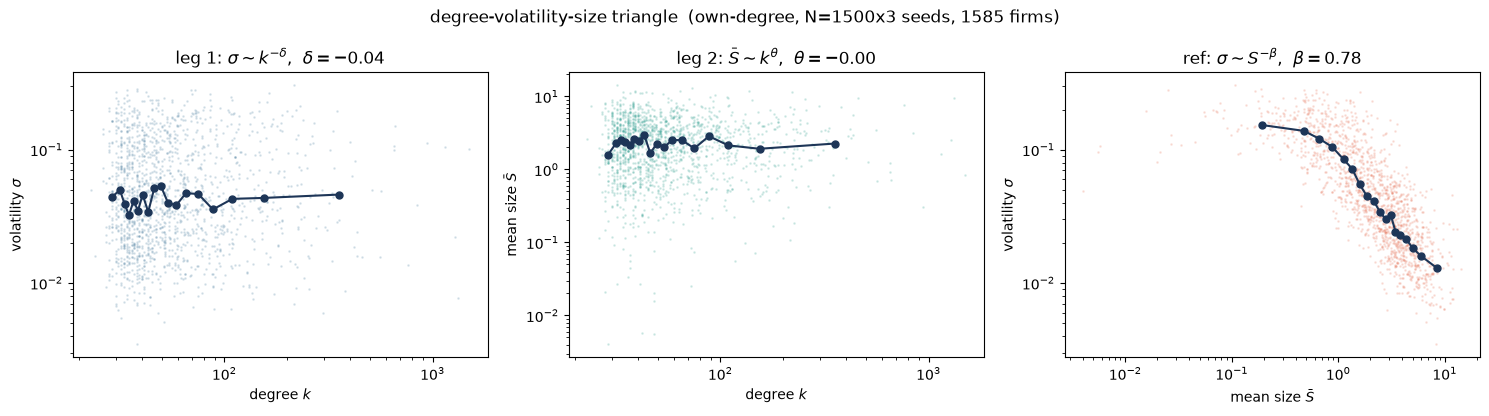

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].loglog(k, vol, ".", ms=2, alpha=0.15, color="#457b9d")
ax[0].loglog(kx_v, ky_v, "o-", ms=5, color="#1d3557")
ax[0].set(xlabel=r"degree $k$", ylabel=r"volatility $\sigma$",
          title=fr"leg 1: $\sigma\sim k^{{-\delta}}$,  $\delta={delta:.2f}$")

ax[1].loglog(k, Sbar, ".", ms=2, alpha=0.15, color="#2a9d8f")
ax[1].loglog(kx_s, ky_s, "o-", ms=5, color="#1d3557")
ax[1].set(xlabel=r"degree $k$", ylabel=r"mean size $\bar S$",
          title=fr"leg 2: $\bar S\sim k^{{\theta}}$,  $\theta={theta:.2f}$")

ax[2].loglog(Sbar, vol, ".", ms=2, alpha=0.15, color="#e76f51")
ax[2].loglog(sx_v, sy_v, "o-", ms=5, color="#1d3557")
ax[2].set(xlabel=r"mean size $\bar S$", ylabel=r"volatility $\sigma$",
          title=fr"ref: $\sigma\sim S^{{-\beta}}$,  $\beta={beta_pool:.2f}$")

fig.suptitle(f"degree-volatility-size triangle  (own-degree, N={N}x{len(recs)} seeds, {k.size} firms)")
plt.tight_layout()
plt.savefig("data/degree_volatility.png", dpi=120)
plt.show()

## Reading the triangle

- **$\delta \approx 0$** → degree does *not* directly set volatility; the size law lives in the dynamics, not the couplings. **$\delta > 0$** → hubs are genuinely quieter, degree is a direct driver.
- **$\theta$** tells you whether hubs grow into the big firms. If $\theta > 0$ and $\delta > 0$, the measured $\sigma\sim S^{-\beta}$ is (partly) a degree law seen through $S(k)$; the consistency check $\theta\cdot\beta \stackrel{?}{=} \delta$ says whether size is degree's *only* channel.
- **leg 3** is the referee: if the size partial $b$ survives with degree held fixed, size carries information degree doesn't (dynamics); if the degree partial $c$ dominates, size is largely a proxy for degree.

Next, if warranted: re-run the same triangle across `fc` / `powerlaw` / `powerlaw_rowavg` to see how each normalization moves $\delta$.